<a href="https://colab.research.google.com/github/shllangermann/dsrp-repo/blob/main/IMPROVED_dsrp26_langermann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSRP 2026 - NYT Best Sellers
Research Question: Among books on the New York Times bestseller list, is greater improvement from debut rank to best rank associated with spending more total weeks on the list?

### **Setup**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

books = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-05-10/nyt_titles.tsv', sep='\t')

In [11]:
print("Original shape:", books.shape)
print(books.info())
print("Missing values:")
print(books.isna().sum())
print("Exact duplicates:", books.duplicated().sum())

Original shape: (7431, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7431 entries, 0 to 7430
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           7431 non-null   int64 
 1   title        7431 non-null   object
 2   author       7427 non-null   object
 3   year         7431 non-null   int64 
 4   total_weeks  7431 non-null   int64 
 5   first_week   7431 non-null   object
 6   debut_rank   7431 non-null   int64 
 7   best_rank    7431 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 464.6+ KB
None
Missing values:
id             0
title          0
author         4
year           0
total_weeks    0
first_week     0
debut_rank     0
best_rank      0
dtype: int64
Exact duplicates: 0


In [12]:
books["first_week"] = pd.to_datetime(
 books["first_week"],
 errors="coerce"
)
books = books.drop_duplicates().copy()

In [14]:
author_fixes = {
 661: "Somerset Maugham",
 1360: "A. P. Herbert",
 2374: "Charles Nordhoff",
 6556: "Elizabeth Goudge",
}
for index, author_name in author_fixes.items():
 if index in books.index and pd.isna(books.loc[index, "author"]):
  books.loc[index, "author"] = author_name

In [15]:
books["rank_improvement"] = (
 books["debut_rank"] - books["best_rank"]
)
print(books.isna().sum())
print(books[["total_weeks", "debut_rank",
 "best_rank", "rank_improvement"]].describe())

id                  0
title               0
author              0
year                0
total_weeks         0
first_week          0
debut_rank          0
best_rank           0
rank_improvement    0
dtype: int64
       total_weeks   debut_rank    best_rank  rank_improvement
count  7431.000000  7431.000000  7431.000000       7431.000000
mean      8.126228     7.897726     6.914278          0.983448
std      11.208171     4.574437     4.567460          6.190178
min       1.000000     1.000000     1.000000        -15.000000
25%       2.000000     4.000000     3.000000         -3.000000
50%       4.000000     8.000000     6.000000          1.000000
75%      10.000000    12.000000    10.000000          5.000000
max     178.000000    17.000000    17.000000         16.000000


In [16]:
rank_issues = books[
 books["best_rank"] > books["debut_rank"]
].copy()
print("Rows where best rank is worse than debut rank:",
 len(rank_issues))
display(
 rank_issues[
 ["id", "title", "debut_rank",
 "best_rank", "rank_improvement"]
 ].head(20)
)

Rows where best rank is worse than debut rank: 2629


,id,title,debut_rank,best_rank,rank_improvement
0,0,"""H"" IS FOR HOMICIDE",1,2,-1
2,10,''G'' IS FOR GUMSHOE,4,8,-4
3,100,A DOG'S JOURNEY,3,14,-11
4,1000,CHANGING FACES,11,14,-3
5,1001,CHAOS,1,7,-6
7,1003,CHARADE,7,10,-3
8,1004,CHARLESTON,7,12,-5
9,1005,CHARLOTTE GRAY,12,17,-5
11,1007,CHARM!,5,13,-8
13,1009,CHARMING BILLY,2,5,-3


### **Exploratory Data Analysis**

In [18]:
books.describe()

,id,year,total_weeks,first_week,debut_rank,best_rank,rank_improvement
count,7431.000000,7431.000000,7431.000000,7431,7431.000000,7431.000000,7431.000000
mean,3715.000000,1989.605168,8.126228,1990-02-09 13:16:03.584981888,7.897726,6.914278,0.983448
min,0.000000,1931.000000,1.000000,1931-10-12 00:00:00,1.000000,1.000000,-15.000000
25%,1857.500000,1968.000000,2.000000,1968-09-25 12:00:00,4.000000,3.000000,-3.000000
50%,3715.000000,2000.000000,4.000000,2000-06-25 00:00:00,8.000000,6.000000,1.000000
75%,5572.500000,2011.000000,10.000000,2011-07-03 00:00:00,12.000000,10.000000,5.000000
max,7430.000000,2020.000000,178.000000,2020-12-06 00:00:00,17.000000,17.000000,16.000000
std,2145.289258,26.234540,11.208171,NaN,4.574437,4.567460,6.190178


In [19]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7431 entries, 0 to 7430
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                7431 non-null   int64         
 1   title             7431 non-null   object        
 2   author            7431 non-null   object        
 3   year              7431 non-null   int64         
 4   total_weeks       7431 non-null   int64         
 5   first_week        7431 non-null   datetime64[ns]
 6   debut_rank        7431 non-null   int64         
 7   best_rank         7431 non-null   int64         
 8   rank_improvement  7431 non-null   int64         
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 522.6+ KB


In [ ]:
bestsell_df = bestsell_df.drop_duplicates()
bestsell_df

,title,author,year,total_weeks,first_week,debut_rank,best_rank
0,"""H"" IS FOR HOMICIDE",Sue Grafton,1991,15,1991-05-05,1,2
1,"""I"" IS FOR INNOCENT",Sue Grafton,1992,11,1992-04-26,14,2
2,''G'' IS FOR GUMSHOE,Sue Grafton,1990,6,1990-05-06,4,8
3,A DOG'S JOURNEY,W. Bruce Cameron,2012,1,2012-05-27,3,14
4,CHANGING FACES,Kimberla Lawson Roby,2006,1,2006-02-19,11,14
...,...,...,...,...,...,...,...
7426,CHANCES,Jackie Collins,1981,1,1981-10-04,1,15
7427,CHANCES ARE ...,Richard Russo,2019,3,2019-08-18,5,8
7428,CHANGE OF HEART,Jodi Picoult,2008,8,2008-03-23,9,1
7429,CHANGES,Danielle Steel,1983,28,1983-09-11,12,2


Plot 1 - Box

/tmp/ipykernel_2105/1674877834.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


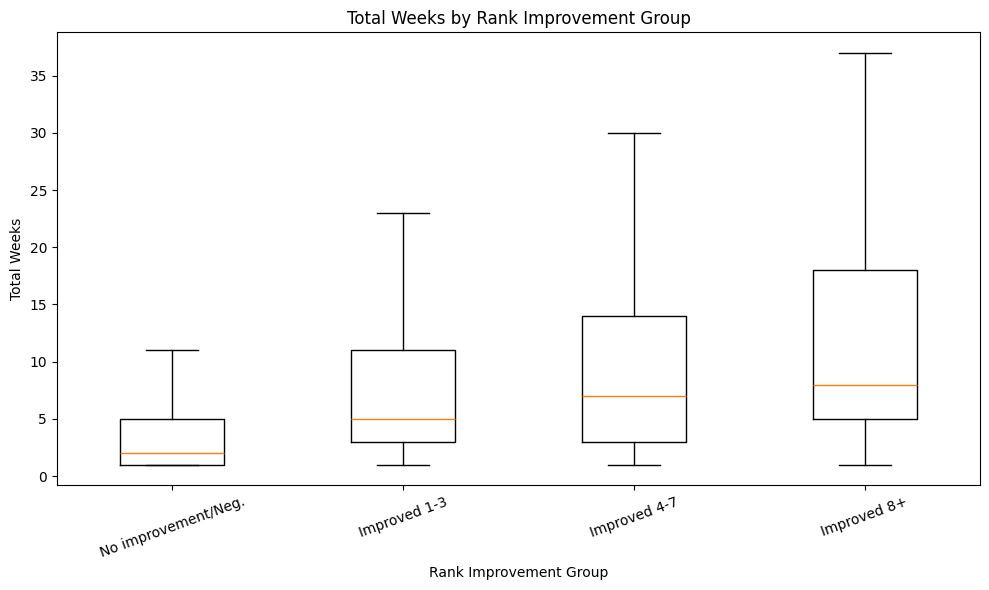

In [27]:
conditions = [
 books["rank_improvement"] <= 0,
 books["rank_improvement"].between(1, 3),
 books["rank_improvement"].between(4, 7),
 books["rank_improvement"] >= 8,
]
labels = [
 "No improvement/Neg.",
 "Improved 1-3",
 "Improved 4-7",
 "Improved 8+",
]
books["improvement_group"] = np.select(
 conditions,
 labels,
 default="Other"
)
group_order = labels
box_data = [
 books.loc[
 books["improvement_group"] == group,
 "total_weeks"
 ]
 for group in group_order
]
plt.figure(figsize=(10, 6))
plt.boxplot(
 box_data,
 labels=group_order,
 showfliers=False
)
plt.title("Total Weeks by Rank Improvement Group")
plt.xlabel("Rank Improvement Group")
plt.ylabel("Total Weeks")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Plot 2 - Line

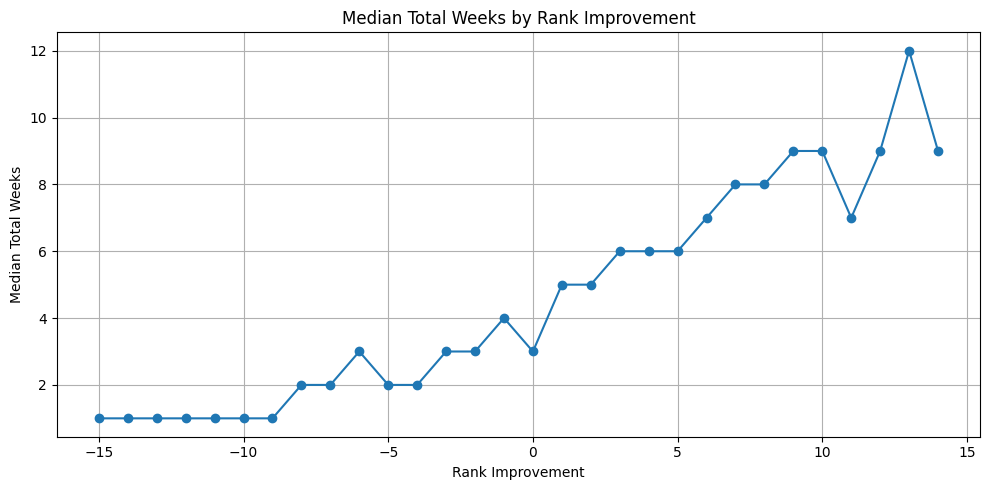

In [24]:
improvement_summary = (
 books.groupby("rank_improvement")["total_weeks"]
 .agg(
 book_count="count",
 median_weeks="median",
 mean_weeks="mean"
 )
 .reset_index()
)
improvement_summary = improvement_summary[
 improvement_summary["book_count"] >= 20
]
plt.figure(figsize=(10, 5))
plt.plot(
 improvement_summary["rank_improvement"],
 improvement_summary["median_weeks"],
 marker="o"
)
plt.title("Median Total Weeks by Rank Improvement")
plt.xlabel("Rank Improvement")
plt.ylabel("Median Total Weeks")
plt.grid(True)
plt.tight_layout()
plt.show()


Plot 3 - Bar

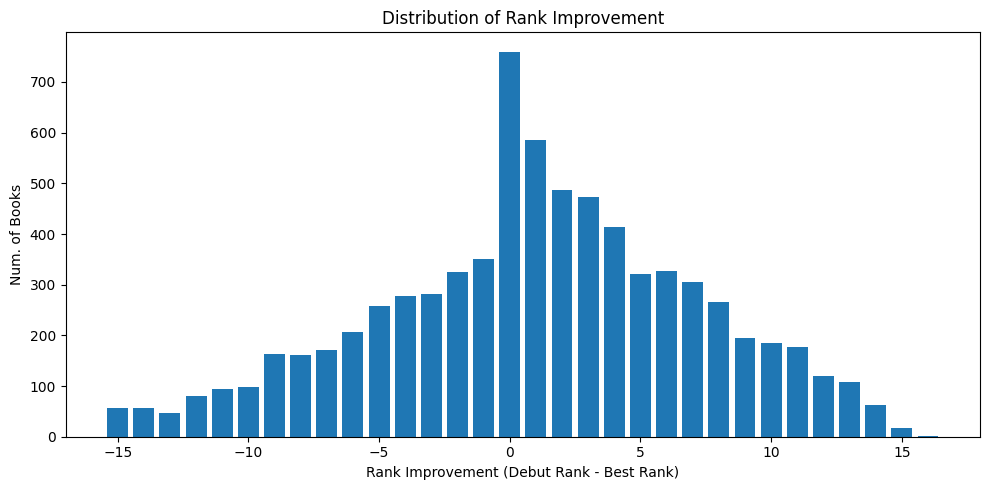

In [23]:
rank_counts = (
 books["rank_improvement"]
 .value_counts()
 .sort_index()
)
plt.figure(figsize=(10, 5))
plt.bar(rank_counts.index, rank_counts.values)
plt.title("Distribution of Rank Improvement")
plt.xlabel("Rank Improvement (Debut Rank - Best Rank)")
plt.ylabel("Num. of Books")
plt.tight_layout()
plt.show()


Plot 4 - Histogram

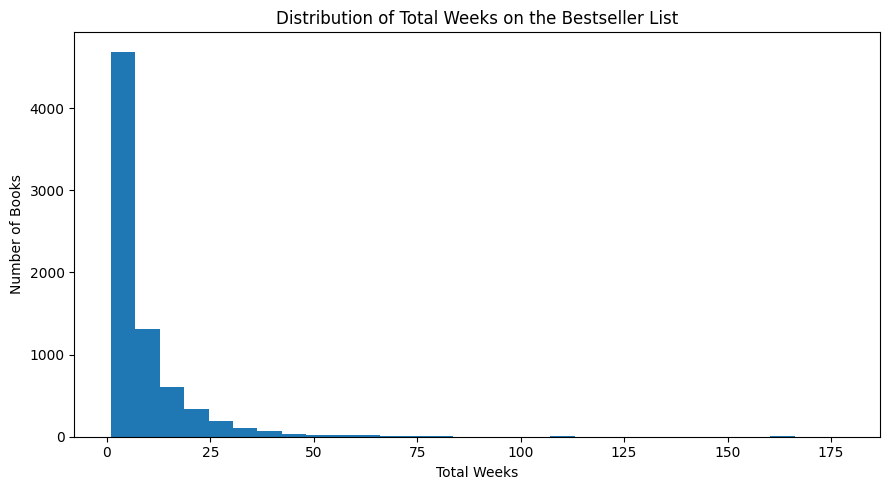

In [20]:
plt.figure(figsize=(9, 5))
plt.hist(books["total_weeks"], bins=30)
plt.title("Distribution of Total Weeks on the Bestseller List")
plt.xlabel("Total Weeks")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

Plot 5 - Scatter

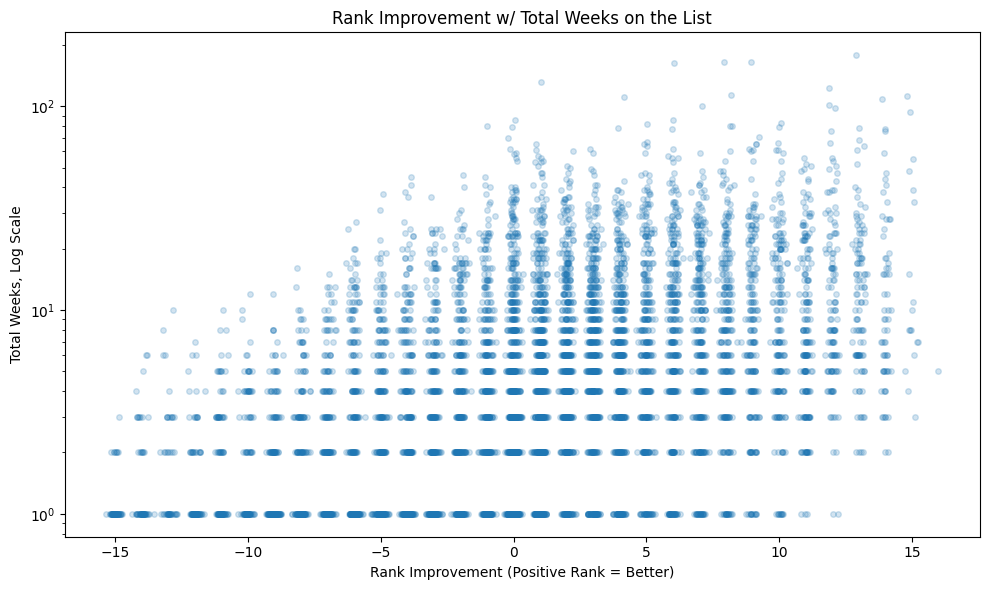

In [25]:
# what is the cause of this pattern??? what could have contributed to this?

rng = np.random.default_rng(42)
x_jittered = (
 books["rank_improvement"]
 + rng.normal(0, 0.12, size=len(books))
)
plt.figure(figsize=(10, 6))
plt.scatter(
 x_jittered,
 books["total_weeks"],
 alpha=0.20,
 s=16
)
plt.yscale("log")
plt.title("Rank Improvement w/ Total Weeks on the List")
plt.xlabel("Rank Improvement (Positive Rank = Better)")
plt.ylabel("Total Weeks, Log Scale")
plt.tight_layout()
plt.show()


Plot 6 - Histogram (Books per decade)

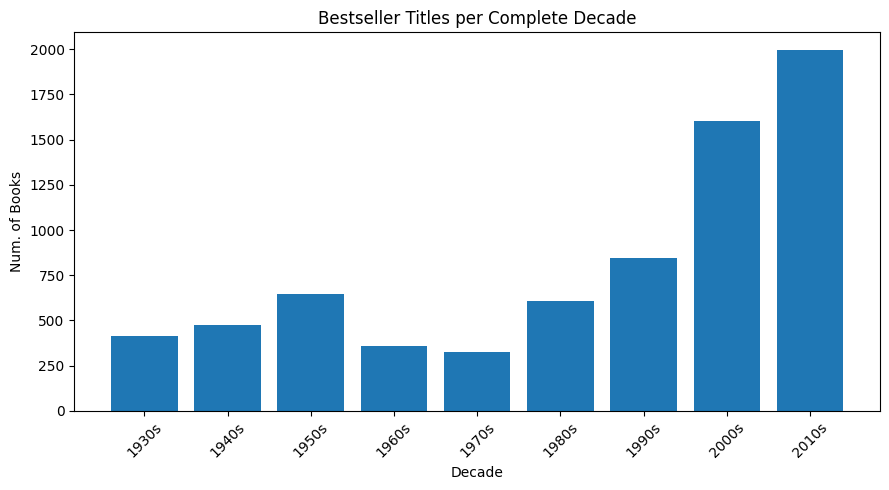

In [30]:
books["decade_start"] = (books["year"] // 10) * 10
books["decade"] = books["decade_start"].astype(str) + "s"
complete_decades = books[books["year"] <= 2019].copy()
decade_counts = (
 complete_decades.groupby(["decade_start", "decade"])
 .size()
 .reset_index(name="book_count")
 .sort_values("decade_start")
)
plt.figure(figsize=(9, 5))
plt.bar(decade_counts["decade"], decade_counts["book_count"])
plt.title("Bestseller Titles per Complete Decade")
plt.xlabel("Decade")
plt.ylabel("Num. of Books")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Statistical Analysis**

H₀: There is no monotonic association between rank improvement and total weeks on the bestseller list.

Hₐ: There is a monotonic association between rank improvement and total weeks on
the bestseller list.

In [31]:
# Spearman Correlation

analysis_df = books[
 ["rank_improvement", "total_weeks"]
].dropna()
rho, p_value = stats.spearmanr(
 analysis_df["rank_improvement"],
 analysis_df["total_weeks"]
)
print("spearman rho:", round(rho, 3))
print("p-value:", p_value)


spearman rho: 0.459
p-value: 0.0


**Interpretation of Results**

A Spearman rank correlation was conducted to examine the association between rank improvement and total weeks on the bestseller list. The analysis produced rho = 0.459 and p = 0 (or p < 0.01). Because p was less than 0.05, we reject the null hypothesis. The direction and magnitude of rho indicate a moderate positive association.

In [ ]:
# visualizations here